In [26]:
### Importing necessary packages
import pandas as pd
import os
from pathlib import Path
import re
import warnings
#warnings.filterwarnings('ignore')
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as col
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import seaborn as sns
import sklearn
from sklearn.cluster import DBSCAN
import urllib.request
import xarray as xr
import itertools
from scipy.stats import gaussian_kde
from sklearn.neighbors import KernelDensity
from scipy.ndimage import gaussian_filter1d

##Add more as needed
## custom packages
from stormevents_utils import standardize_and_convert_to_utc, build_begin_datetime, load_stormevents_data

In [2]:
# Loading in the data
data_dir = Path("/data1/lepique/stormevents_details/")  

df_scs = load_stormevents_data(data_dir)

Found 76 files
Reading StormEvents_details-ftp_v1.0_d1950_c20250520.csv.gz (year=1950)
Reading StormEvents_details-ftp_v1.0_d1951_c20250520.csv.gz (year=1951)
Reading StormEvents_details-ftp_v1.0_d1952_c20250520.csv.gz (year=1952)
Reading StormEvents_details-ftp_v1.0_d1953_c20250520.csv.gz (year=1953)
Reading StormEvents_details-ftp_v1.0_d1954_c20250520.csv.gz (year=1954)
Reading StormEvents_details-ftp_v1.0_d1955_c20250520.csv.gz (year=1955)
Reading StormEvents_details-ftp_v1.0_d1956_c20250520.csv.gz (year=1956)
Reading StormEvents_details-ftp_v1.0_d1957_c20250520.csv.gz (year=1957)
Reading StormEvents_details-ftp_v1.0_d1958_c20250520.csv.gz (year=1958)
Reading StormEvents_details-ftp_v1.0_d1959_c20250520.csv.gz (year=1959)
Reading StormEvents_details-ftp_v1.0_d1960_c20250520.csv.gz (year=1960)
Reading StormEvents_details-ftp_v1.0_d1961_c20250520.csv.gz (year=1961)
Reading StormEvents_details-ftp_v1.0_d1962_c20250520.csv.gz (year=1962)
Reading StormEvents_details-ftp_v1.0_d1963_c20250

In [3]:
df_scs

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE,BEGIN_DT,WINTER_SEASON,SOURCE_FILE_YEAR,BEGIN_DT_UTC
0,195004,28,1445,195004,28,1445,NaN,10096222,OKLAHOMA,40.0,...,-99.20,35.17,-99.20,NaN,NaN,PUB,1950-04-28 14:45:00,1950,1950,1950-04-28 20:45:00+00:00
1,195004,29,1530,195004,29,1530,NaN,10120412,TEXAS,48.0,...,-98.60,31.73,-98.60,NaN,NaN,PUB,1950-04-29 15:30:00,1950,1950,1950-04-29 21:30:00+00:00
2,195007,5,1800,195007,5,1800,NaN,10104927,PENNSYLVANIA,42.0,...,-75.70,40.65,-75.47,NaN,NaN,PUB,1950-07-05 18:00:00,1950,1950,1950-07-05 23:00:00+00:00
3,195007,5,1830,195007,5,1830,NaN,10104928,PENNSYLVANIA,42.0,...,-76.75,NaN,NaN,NaN,NaN,PUB,1950-07-05 18:30:00,1950,1950,1950-07-05 23:30:00+00:00
4,195007,24,1440,195007,24,1440,NaN,10104929,PENNSYLVANIA,42.0,...,-79.68,NaN,NaN,NaN,NaN,PUB,1950-07-24 14:40:00,1950,1950,1950-07-24 19:40:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062846,202509,16,1427,202509,16,1427,207582.0,1294667,NEBRASKA,31.0,...,-101.60,41.13,-101.60,"Thunderstorms developed around midday, along a...",NaN,CSV,2025-09-16 14:27:00,2025,2025,2025-09-16 20:27:00+00:00
1062847,202509,16,1453,202509,16,1453,207582.0,1294668,NEBRASKA,31.0,...,-101.58,41.13,-101.58,"Thunderstorms developed around midday, along a...",Half dollar size hail reported on Interstate 8...,CSV,2025-09-16 14:53:00,2025,2025,2025-09-16 20:53:00+00:00
1062848,202509,16,1454,202509,16,1454,207582.0,1294669,NEBRASKA,31.0,...,-101.34,41.19,-101.34,"Thunderstorms developed around midday, along a...",Public reports quarter sized hail along with t...,CSV,2025-09-16 14:54:00,2025,2025,2025-09-16 20:54:00+00:00
1062849,202509,9,1658,202509,9,1658,207120.0,1294428,TEXAS,48.0,...,-101.81,35.34,-101.81,"On the evening of September 9th, a very subtle...",A 59mph wind gust was measured at the mesonet ...,CSV,2025-09-09 16:58:00,2025,2025,2025-09-09 21:58:00+00:00


In [4]:
## Subsetting winter months:
winter_months = {12, 1, 2, 3}
df_winter_scs = df_scs[df_scs["BEGIN_DT"].dt.month.isin(winter_months)]

In [5]:
df_winter_scs['EVENT_TYPE'].unique()

array(['Tornado', 'Thunderstorm Wind', 'Hail'], dtype=object)

In [6]:
df_winter_scs

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE,BEGIN_DT,WINTER_SEASON,SOURCE_FILE_YEAR,BEGIN_DT_UTC
225,195103,28,510,195103,28,510,NaN,10120421,TEXAS,48.0,...,-95.6000,NaN,NaN,NaN,NaN,PUB,1951-03-28 05:10:00,1950,1951,1951-03-28 11:10:00+00:00
229,195103,30,1500,195103,30,1500,NaN,10104933,PENNSYLVANIA,42.0,...,-77.2300,NaN,NaN,NaN,NaN,PUB,1951-03-30 15:00:00,1950,1951,1951-03-30 21:00:00+00:00
234,195102,19,1830,195102,19,1830,NaN,10099493,OKLAHOMA,40.0,...,-98.1800,35.3700,-98.1300,NaN,NaN,PUB,1951-02-19 18:30:00,1950,1951,1951-02-20 00:30:00+00:00
271,195102,19,1835,195102,19,1835,NaN,10099704,OKLAHOMA,40.0,...,-98.1300,35.8300,-97.8300,NaN,NaN,PUB,1951-02-19 18:35:00,1950,1951,1951-02-20 00:35:00+00:00
272,195102,19,2200,195102,19,2200,NaN,10099705,OKLAHOMA,40.0,...,-97.4500,NaN,NaN,NaN,NaN,PUB,1951-02-19 22:00:00,1950,1951,1951-02-20 04:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1056239,202503,30,2320,202503,30,2320,206867.0,1290825,KENTUCKY,21.0,...,-83.3841,38.1571,-83.3841,A deep low pressure system (including a surfac...,Powerlines were reported to have blown down at...,CSV,2025-03-30 23:20:00,2024,2025,2025-03-31 03:20:00+00:00
1056240,202503,31,20,202503,31,20,206867.0,1290828,KENTUCKY,21.0,...,-83.7779,37.1871,-83.7779,A deep low pressure system (including a surfac...,A tree was reported to have been blown down ne...,CSV,2025-03-31 00:20:00,2024,2025,2025-03-31 04:20:00+00:00
1056244,202503,31,119,202503,31,119,206867.0,1290851,KENTUCKY,21.0,...,-82.5863,37.3389,-82.5863,A deep low pressure system (including a surfac...,Powerlines were reported to have been blown do...,CSV,2025-03-31 01:19:00,2024,2025,2025-03-31 05:19:00+00:00
1056246,202503,27,200,202503,27,200,200858.0,1249986,TEXAS,48.0,...,-97.1590,26.0711,-97.1590,Several rounds of showers and thunderstorms pu...,"The C-MAN station at Brazos Santiago, just ins...",CSV,2025-03-27 02:00:00,2024,2025,2025-03-27 07:00:00+00:00


## Decadal plots to compare "hotspots"

In [7]:
decades = [
    ("1996-2005", 1996, 2005),
    ("2006-2015", 2006, 2015),
    ("2016-2025", 2016, 2025)
]

In [21]:
proj = ccrs.LambertConformal(
    central_longitude=-96, central_latitude=39,
    standard_parallels=(33, 45),
)

plate = ccrs.PlateCarree()


event_type = "wind"   # "hail", "tornado", "wind"
extent = [-130, -65, 23, 50]   # lon_min, lon_max, lat_min, lat_max

# KDE smoothness (in meters since we're in projected coordinates)
bandwidth_m = 150_000  # try 150_000 to 300_000

# Grid for evaluation (in lon/lat, then transformed to proj x/y)
nlon, nlat = 280, 170
lon = np.linspace(extent[0], extent[1], nlon)
lat = np.linspace(extent[2], extent[3], nlat)
LON, LAT = np.meshgrid(lon, lat)

grid_xy = proj.transform_points(plate, LON, LAT)[..., :2]
GX, GY = grid_xy[..., 0], grid_xy[..., 1]
grid_valid = np.isfinite(GX) & np.isfinite(GY)
grid_points = np.column_stack([GX[grid_valid], GY[grid_valid]])

In [22]:
# ----------------------------
# Event mask helper
# ----------------------------
def event_mask(et_series, event_type):
    et = et_series.str.upper().fillna("OTHER")
    e = event_type.lower()
    if e.startswith("tornado"):
        return et.str.contains("TORNADO")
    if e.startswith("hail"):
        return et.str.contains("HAIL")
    return et.str.contains("THUNDERSTORM WIND")


In [23]:
### Running Kernel Density Estimation for each decade
kde_maps = {}

for label, y0, y1 in decades:
    d = df_winter_scs[
        (df_winter_scs["WINTER_SEASON"] >= y0) &
        (df_winter_scs["WINTER_SEASON"] <= y1)
    ].copy()

    d = d[event_mask(d["EVENT_TYPE"], event_type)]
    d = d.dropna(subset=["BEGIN_LAT", "BEGIN_LON"])

    # keep points in plotting extent (just to be sure)
    d = d[
        (d["BEGIN_LON"] >= extent[0]) & (d["BEGIN_LON"] <= extent[1]) &
        (d["BEGIN_LAT"] >= extent[2]) & (d["BEGIN_LAT"] <= extent[3])
    ]

    if d.empty:
        print(f"No {event_type} reports for {label}")
        kde_maps[label] = None
        continue

    pts_xy = proj.transform_points(
        plate,
        d["BEGIN_LON"].to_numpy(),
        d["BEGIN_LAT"].to_numpy()
    )[:, :2]
    pts_xy = pts_xy[np.isfinite(pts_xy).all(axis=1)]

    if len(pts_xy) < 5:
        print(f"Too few points for KDE in {label}")
        kde_maps[label] = None
        continue

    kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth_m)
    kde.fit(pts_xy)

    log_dens = np.full(LON.shape, np.nan)
    log_dens[grid_valid] = kde.score_samples(grid_points)
    dens = np.exp(log_dens)

    # Normalize to sum to 1 over map (relative footprint per decade)
    # Area weighting because grid is in lon/lat
    area_w = np.cos(np.deg2rad(LAT))
    total = np.nansum(dens * area_w)
    dens_norm = dens / total if total > 0 else dens

    kde_maps[label] = dens_norm


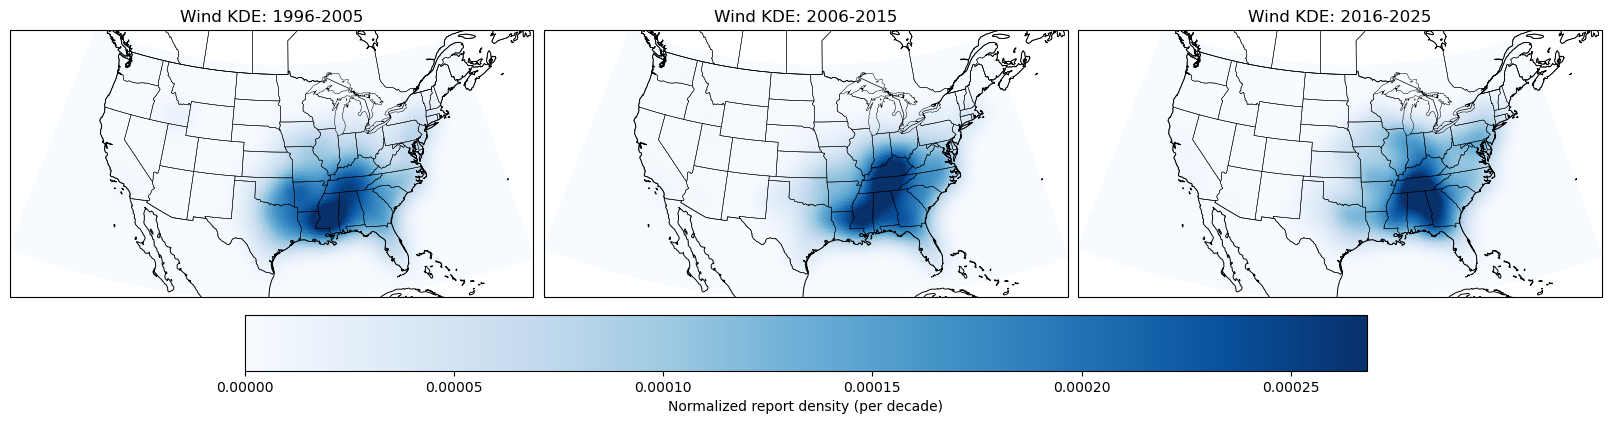

In [24]:
## Make plots
all_vals = np.concatenate([
    m[np.isfinite(m)] for m in kde_maps.values() if m is not None
])
vmax = np.nanpercentile(all_vals, 99)  # robust shared scale

fig, axes = plt.subplots(
    1, 3, figsize=(16, 5),
    subplot_kw={"projection": proj},
    constrained_layout=True
)

for ax, (label, _, _) in zip(axes, decades):
    ax.set_extent(extent, crs=plate)
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.7)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)
    ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.35)
    ax.set_title(f"{event_type.title()} KDE: {label}")

    Z = kde_maps[label]
    if Z is None:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes,
                ha="center", va="center")
        continue

    im = ax.pcolormesh(
        LON, LAT, Z,
        transform=plate, shading="auto",
        cmap="Blues", vmin=0, vmax=vmax
    )

cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=0.8, pad=0.04)
cbar.set_label("Normalized report density (per decade)")
fig.savefig('kde_wind.png', dpi=300)
plt.show()

## Seasonal Timing Shift:

In [ ]:
d = df_winter_scs.copy()


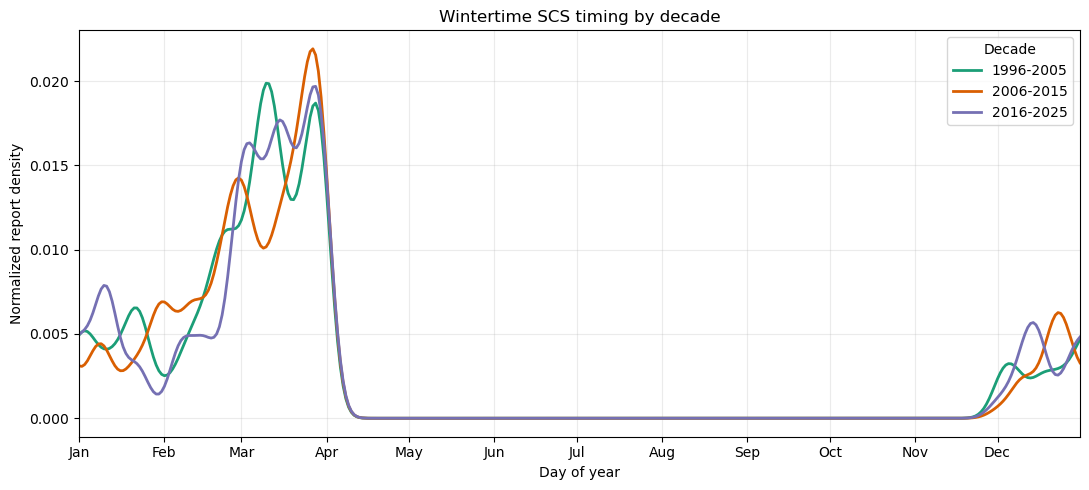

1996-2005: peak DOY 69 (Mar 10)
2006-2015: peak DOY 86 (Mar 27)
2016-2025: peak DOY 87 (Mar 28)


In [27]:
decades = [
    ("1996-2005", 1996, 2005),
    ("2006-2015", 2006, 2015),
    ("2016-2025", 2016, 2025),
]

# --- prep ---
d = df_winter_scs.copy()
d = d.dropna(subset=["BEGIN_DT_UTC", "WINTER_SEASON"])

# Remove Feb 29 so every year maps to 365-day axis consistently
is_feb29 = (d["BEGIN_DT_UTC"].dt.month == 2) & (d["BEGIN_DT_UTC"].dt.day == 29)
d = d.loc[~is_feb29].copy()

# Day-of-year on a 365-day scale
d["DOY"] = d["BEGIN_DT_UTC"].dt.dayofyear
# In leap years, dates after Feb 28 need -1 after removing Feb 29
is_leap = d["BEGIN_DT_UTC"].dt.is_leap_year
after_feb28 = (d["BEGIN_DT_UTC"].dt.month > 2)
d.loc[is_leap & after_feb28, "DOY"] -= 1

# --- plot ---
fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#1b9e77", "#d95f02", "#7570b3"]
peak_info = []

for (label, y0, y1), c in zip(decades, colors):
    dd = d[(d["WINTER_SEASON"] >= y0) & (d["WINTER_SEASON"] <= y1)]
    if dd.empty:
        continue

    # Probability distribution over DOY (1..365)
    counts = np.bincount(dd["DOY"].astype(int), minlength=366)[1:]
    p = counts / counts.sum()

    # Smooth (optional) to show seasonal signal
    p_smooth = gaussian_filter1d(p, sigma=4, mode="wrap")  # ~4-day smoothing

    x = np.arange(1, 366)
    ax.plot(x, p_smooth, lw=2, color=c, label=label)

    peak_doy = int(x[np.argmax(p_smooth)])
    peak_date = (pd.Timestamp("2001-01-01") + pd.Timedelta(days=peak_doy - 1)).strftime("%b %d")
    peak_info.append((label, peak_doy, peak_date))

# Month tick marks
month_starts = pd.date_range("2001-01-01", "2001-12-01", freq="MS")
month_ticks = [(dt - pd.Timestamp("2001-01-01")).days + 1 for dt in month_starts]
month_labels = [dt.strftime("%b") for dt in month_starts]
ax.set_xticks(month_ticks)
ax.set_xticklabels(month_labels)

ax.set_xlim(1, 365)
ax.set_ylabel("Normalized report density")
ax.set_xlabel("Day of year")
ax.set_title("Wintertime SCS timing by decade")
ax.legend(title="Decade")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Print peak timing
for label, peak_doy, peak_date in peak_info:
    print(f"{label}: peak DOY {peak_doy} ({peak_date})")
